$$\frac{\partial T}{\partial t} - \nu \frac{\partial ^2 T}{\partial x^2} - \nu \frac{\partial ^2 T}{\partial y^2} = -\nu ((6x-4)(y^4-2y^3+y^2) + (x^3-2x^2+x)(12y^3-12y+2))$$


---



* Analítica: $T(x,y,t) = x(x-1)^2 y^2 (y-1)^2$
* $T(0,y,t) = 0$
* $T(1,y,t) = 1$
* $\dfrac{\partial T}{\partial y} = 0,$ para $y=0$ e $y=1$
* $T(x,y,0) = T$


---



# Bibliotecas

In [2]:
#------------------- Bibliotecas utilizadas --------------------------
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt
from IPython.display import display, Math, Latex
from os import name

import time
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline

from devito import Grid, Function, TimeFunction, Operator, configuration, Eq, solve, Constant
from sympy import nsimplify, pprint
from devito.logger import warning
from examples.cfd import plot_field, init_hat

# Problema

In [4]:
nx = 41
ny = nx

nu = 1

dx = 1. / (nx - 1)
dy = 1. / (ny - 1)
sigma = .25
dt = sigma * dx * dy / nu

tstop = 1
nt = round(tstop/dt)

In [5]:
x0         = 0
x1         = 1
compx      = x1-x0
y0         = 0
y1         = 1
compy      = y1-y0

In [6]:
origin = (x0,y0)
extent = (compx,compy)
shape  = (nx,ny)
grid   = Grid(origin=origin,extent=extent,shape=shape)

In [7]:
(x, y)  = grid.dimensions
time    = grid.time_dim
t       = grid.stepping_dim

In [8]:
xf = Function(name ='xf', shape=(nx,), dimensions=(x,))
xf.data[:] = np.linspace(0, 1, nx)

yf = Function(name ='yf', shape=(ny,), dimensions=(y,))
yf.data[:] = np.linspace(0, 1, ny)

In [9]:
f = Function(name='f', shape=(nx,ny), dimensions=(x,y))
for i in range(nx):
    for j in range(ny):
      f.data[i,j] =  - nu* ((6*xf.data[i] - 4) * (yf.data[j] + 1))

#f.data[:]

In [10]:
u = TimeFunction(name='u', grid=grid, space_order=2)
right = f


eq = Eq(u.dt - nu * (u.laplace), right)
stencil = solve(eq, u.forward)
eq_stencil = Eq(u.forward, stencil)

eq_stencil

Eq(u(t + dt, x, y), dt*(f(x, y) + Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2)) + u(t, x, y)/dt))

In [11]:
eq_stencil.evaluate

Eq(u(t + dt, x, y), dt*(-2.0*u(t, x, y)/h_x**2 + u(t, x - h_x, y)/h_x**2 + u(t, x + h_x, y)/h_x**2 - 2.0*u(t, x, y)/h_y**2 + u(t, x, y - h_y)/h_y**2 + u(t, x, y + h_y)/h_y**2 + f(x, y) + u(t, x, y)/dt))

In [12]:
# Initial Condiotion
u.data[0] = 0

# Boundary Conditions
bc = [Eq(u[t+1,0, y], 0)]  # p = 0 @ x = 0
bc += [Eq(u[t+1,nx-1, y], 0)]  # p = y @ x = 1

bc += [Eq(u[t+1,x, 0], u[t+1,x, 1])]  # dp/dy = 0 @ y = 0
bc += [Eq(u[t+1,x, ny-1], u[t+1,x, ny-2])]  # dp/dy = 0 @ y = 1


op = Operator([eq_stencil] + bc)

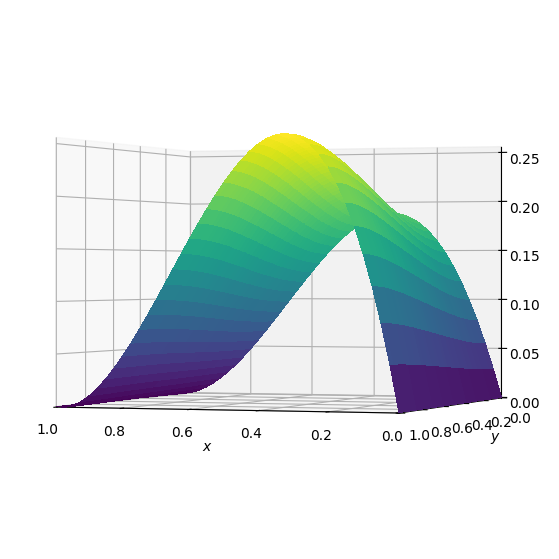

In [13]:
configuration['log-level'] = 'ERROR'

op(time=nt-1,dt = dt)

plot_field(u.data[0], xmin=x0, xmax=x1, ymin=y0, ymax=y1, view=(0,110))

In [16]:
import numpy as np
import plotly.graph_objects as go

In [17]:
# Create interactive 3D surface plot
fig = go.Figure(data=[go.Surface(z=u.data[0].T, x=xf.data[:], y=yf.data[:])])
fig.show()

## Analítica

In [18]:
def analytic_solution(x, y):
  """Calculates the analytic solution f(x, y) = cos(x) + y^3."""
  return x * ((x-1)**2) * (y+1)

In [19]:
X, Y = np.meshgrid(xf.data[:], yf.data[:])

In [20]:
analytic_values = analytic_solution(X, Y)

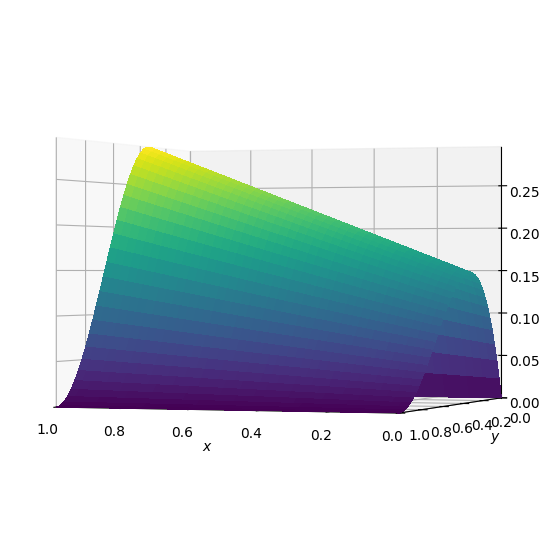

In [25]:
plot_field(analytic_values, xmin=x0, xmax=x1, ymin=y0, ymax=y1, view=(0,110))

# Completo

In [28]:
def plot_3d_comparison(x, y, numerical_solution, analytical_solution):
    """
    Plota comparação 3D entre solução numérica (superfície) e analítica (pontos)

    Parâmetros:
    x : array 1D - coordenadas x da malha
    y : array 1D - coordenadas y da malha
    numerical_solution : array 2D - solução numérica em toda a malha
    analytical_solution : array 2D - solução analítica em toda a malha
    """
    # Cria malha para plotagem 3D
    X, Y = np.meshgrid(x, y, indexing='ij')

    fig = plt.figure(figsize=(14, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plota superfície da solução numérica
    surf = ax.plot_surface(X, Y, numerical_solution.T,
                          cmap='viridis', alpha=0.7,
                          label='Solução Numérica')

    # Plota pontos da solução analítica (mostrando 1 a cada 2 pontos para melhor visualização)
    scatter = ax.scatter(X[::2,::2], Y[::2,::2], analytical_solution.T[::2,::2],
                        color='red', s=50, depthshade=True,
                        label='Solução Analítica')

    # Configurações do gráfico
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('y', fontsize=12)
    ax.set_zlabel('T(t,x,y)', fontsize=12)

    # Criando legendas manualmente
    surf._edgecolors2d = surf._edgecolor3d
    surf._facecolors2d = surf._facecolor3d
    ax.legend()

    # Ajusta a visualização
    ax.view_init(elev=30, azim=45)
    plt.tight_layout()
    plt.show()

def run_simulation(nx_values=[21, 41, 81, 161]):
    convergence_results = []
    all_results = {}

    for nx in nx_values:
        print(f"\nRunning simulation for nx = {nx}\n")
        ny = nx
        nu = 1

        x0 = 0
        x1 = 1
        compx = x1 - x0
        y0 = 0
        y1 = 1
        compy = y1 - y0
        dx = compx / (nx - 1)
        dy = compy / (ny - 1)
        sigma = 0.25
        dt = sigma * dx * dy / nu

        tstop = 1
        nt = round(tstop / dt)

        origin = (x0, y0)
        extent = (compx, compy)
        shape = (nx, ny)
        grid = Grid(origin=origin, extent=extent, shape=shape)
        (x, y) = grid.dimensions
        time = grid.time_dim
        t = grid.stepping_dim

        f = Function(name='f', shape=(nx,ny), dimensions=(x,y), grid = grid)
        X, Y = np.meshgrid(np.linspace(x0, x1, nx), np.linspace(y0, y1, ny), indexing='ij')
        f_data = - nu * ((6*X - 4)*(Y**4 - 2*(Y**3) + Y**2) + (X**3 - 2*(X**2) + X)*(12*(Y**2) - 12*Y + 2))
        f.data[:] = f_data.reshape((nx, ny))

        u = TimeFunction(name='u', grid=grid, space_order=2)
        eq = Eq(u.dt - nu * (u.laplace), f)
        stencil = solve(eq, u.forward)
        eq_stencil = Eq(u.forward, stencil)

        u.data[0] = X * ((X-1)**2) * (Y**2) * ((Y-1)**2)

        # Boundary Conditions
        bc = [Eq(u[t + 1, 0, y], 0.)]
        bc += [Eq(u[t + 1, nx - 1, y], 0)]
        bc += [Eq(u[t + 1, x, 0], 0)]#u[t + 1, x, 1])]
        bc += [Eq(u[t + 1, x, ny - 1], 0)]#u[t + 1, x, ny - 2])]

        op = Operator([eq_stencil] + bc)
        configuration['log-level'] = 'ERROR'
        op(time=nt, dt=dt)

        # Plot field
        plot_field(u.data[0], xmin=x0, xmax=x1, ymin=y0, ymax=y1)

        # Analytical Solution
        x_analytical = np.linspace(x0, x1, nx)
        y_analytical = np.linspace(y0, y1, ny)
        T_analytical = X * ((X-1)**2) * (Y**2) * ((Y-1)**2)

        # Comparison Plot
        plt.figure(figsize=(10, 6))
        plt.plot(x_analytical, T_analytical[:,ny//2], label='Solução Analítica', marker='o')
        plt.plot(x_analytical, u.data[0, :, ny//2], label='Solução Numérica', marker='x')
        plt.xlabel('x')
        plt.ylabel('T(t,x,y)')
        plt.legend()
        plt.grid(True)
        plt.show()

        # Plot 3D
        plot_3d_comparison(x_analytical,y_analytical, u.data[0], T_analytical)

        # Relative Error Plot
        relative_error = np.sqrt(np.sum((T_analytical - u.data)**2 )) / np.sqrt(np.sum((T_analytical)**2 ))

        # Store results for convergence analysis
        all_results[nx] = {
            'x': X,
            'numerical': u.data[0],
            'analytical': T_analytical,
            'rel_error': relative_error,
            'h': dx,
            'dt': dt
        }

    # Calculate convergence rates
    nx_sorted = sorted(all_results.keys())
    for i, nx in enumerate(nx_sorted):
        if i == 0:
            q_h = np.nan
            q_dt = np.nan
        else:
            prev_nx = nx_sorted[i-1]
            E1 = all_results[prev_nx]['rel_error']
            E2 = all_results[nx]['rel_error']
            h1 = all_results[prev_nx]['h']
            h2 = all_results[nx]['h']
            dt1 = all_results[prev_nx]['dt']
            dt2 = all_results[nx]['dt']

            q_h = np.log(E1/E2) / np.log(h1/h2)
            q_dt = np.log(E1/E2) / np.log(dt1/dt2)

        convergence_results.append({
            'N': nx,
            'h': all_results[nx]['h'],
            'dt_cfl': all_results[nx]['dt'],
            'Erro': all_results[nx]['rel_error'],
            'q_h': q_h,
            'q_dt_cfl': q_dt
        })

    df_convergence = pd.DataFrame(convergence_results)
    print("\nConvergence Analysis Table:")
    print(df_convergence.to_string(float_format="%.4e"))

    return all_results, df_convergence


Running simulation for nx = 11



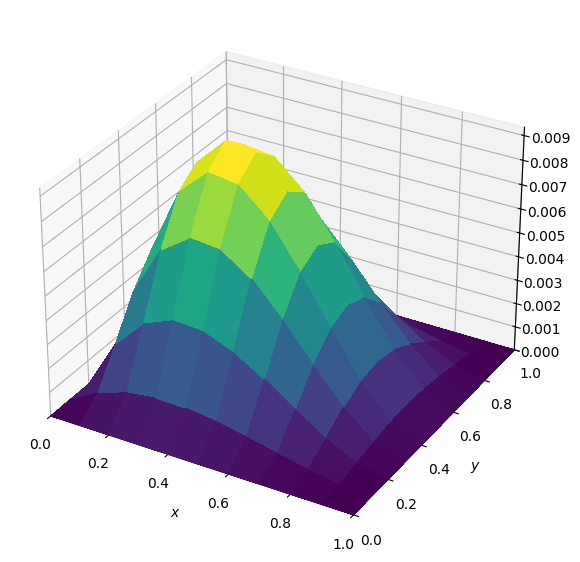

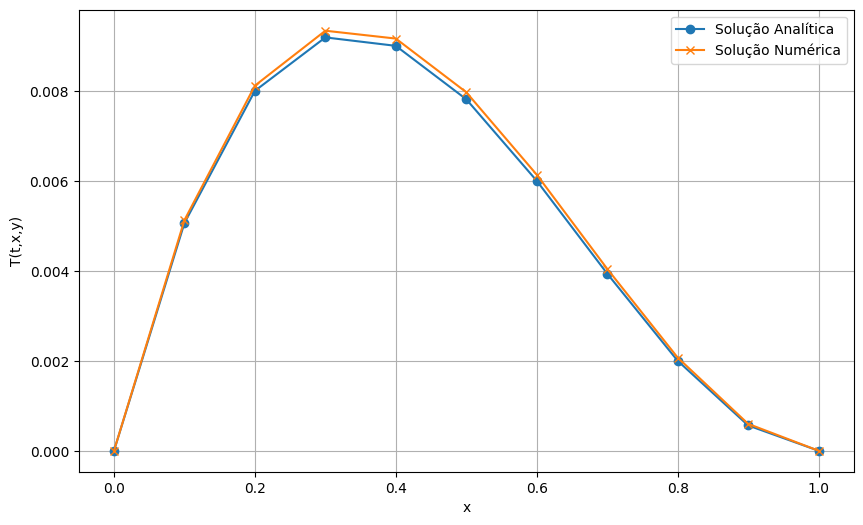

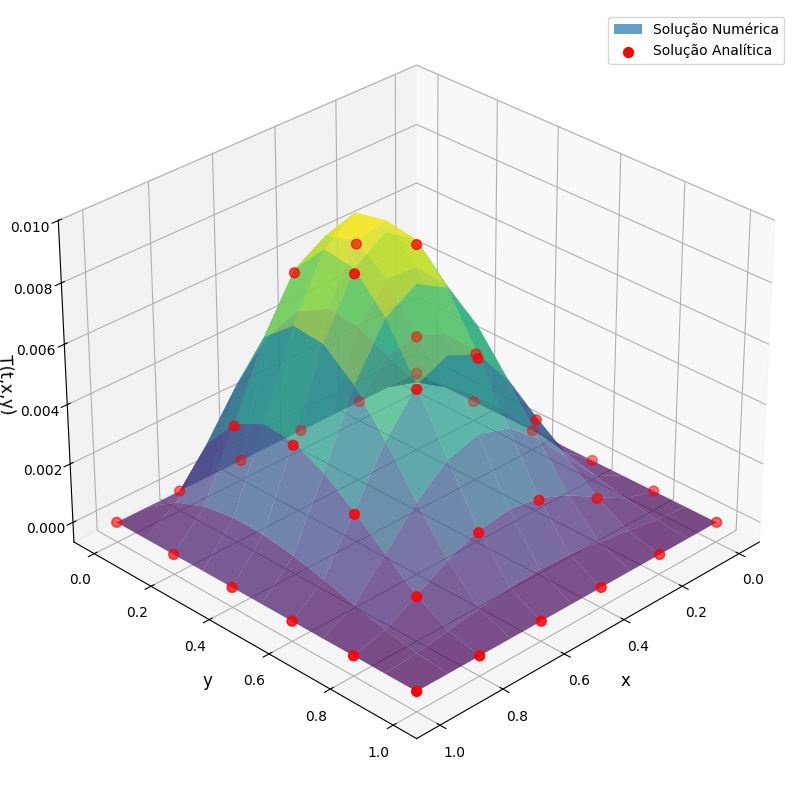


Running simulation for nx = 21



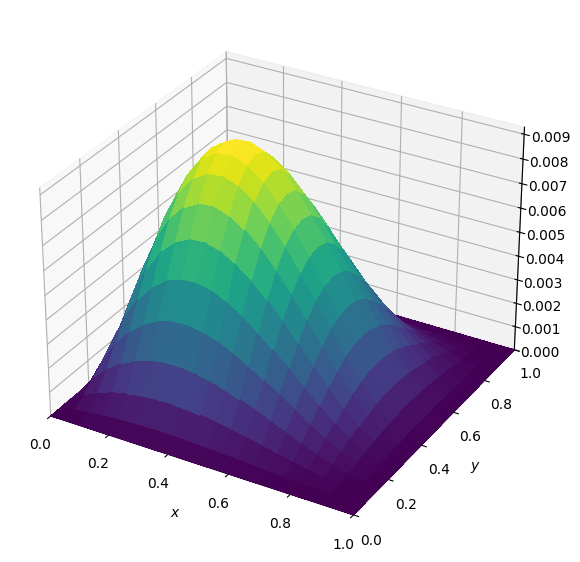

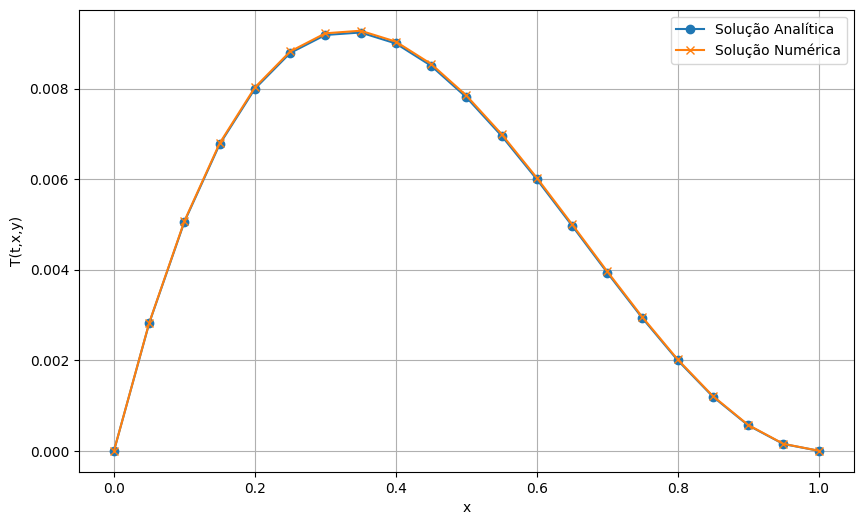

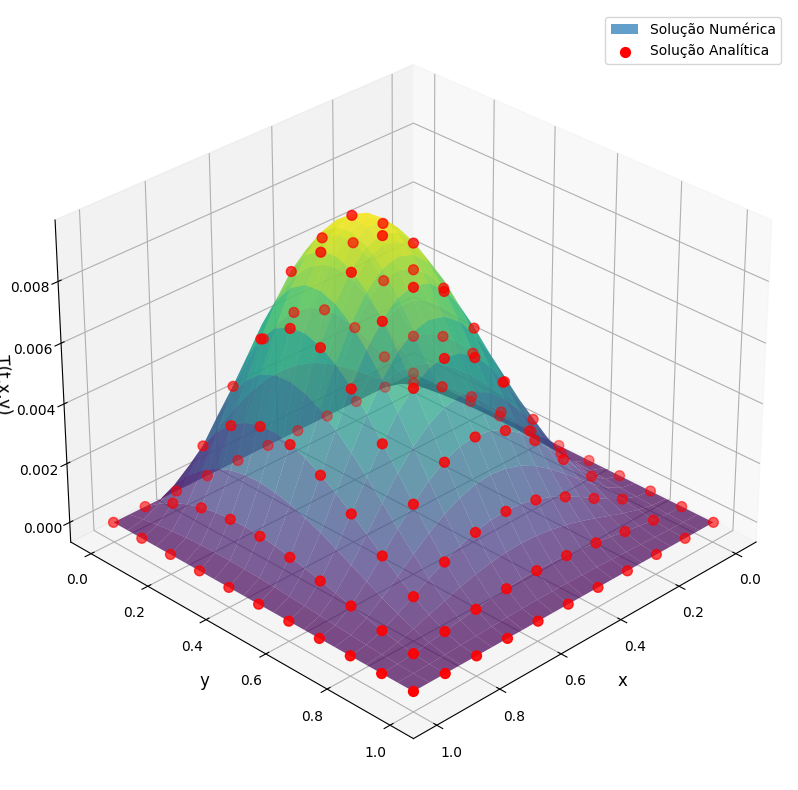


Running simulation for nx = 41



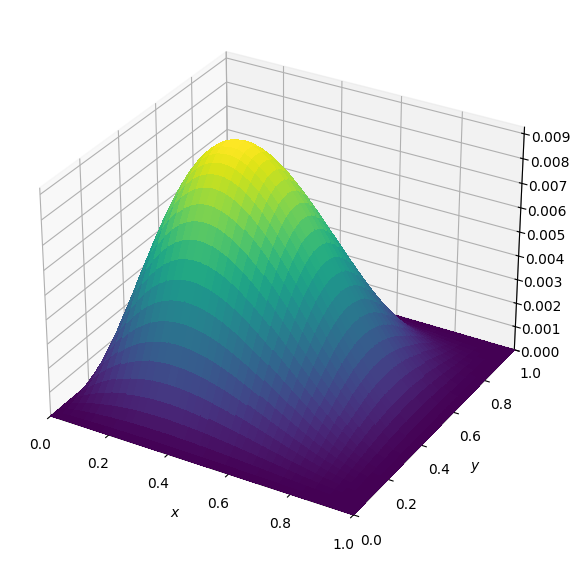

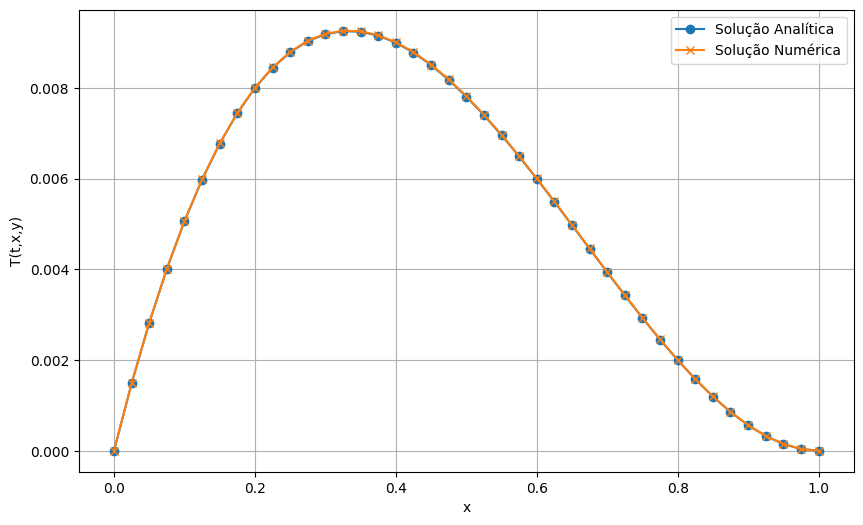

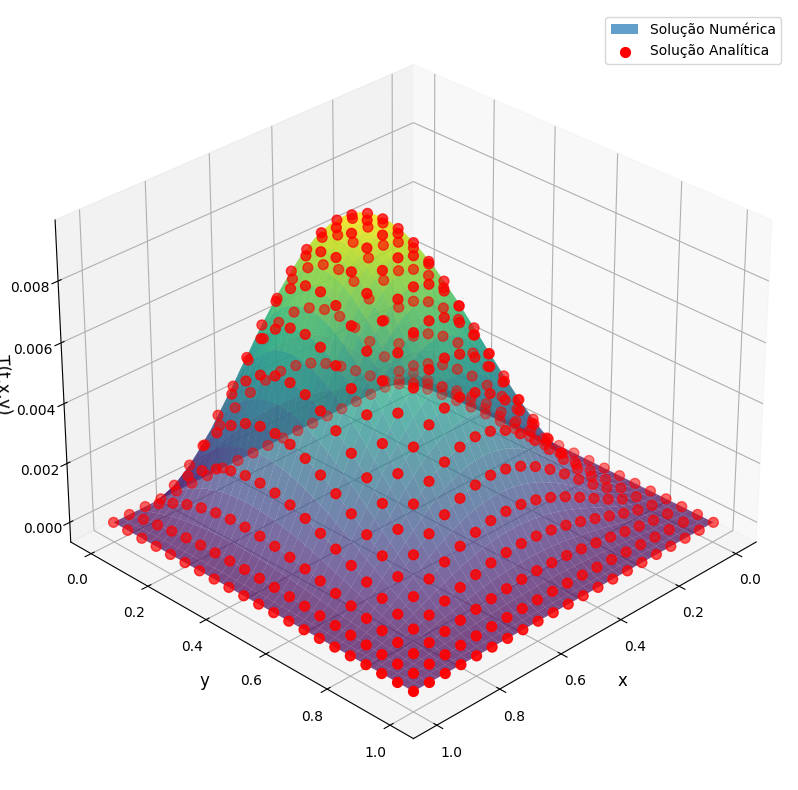


Running simulation for nx = 81



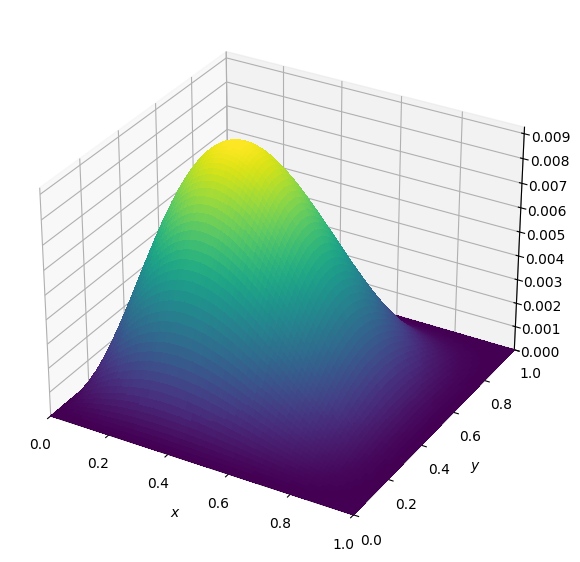

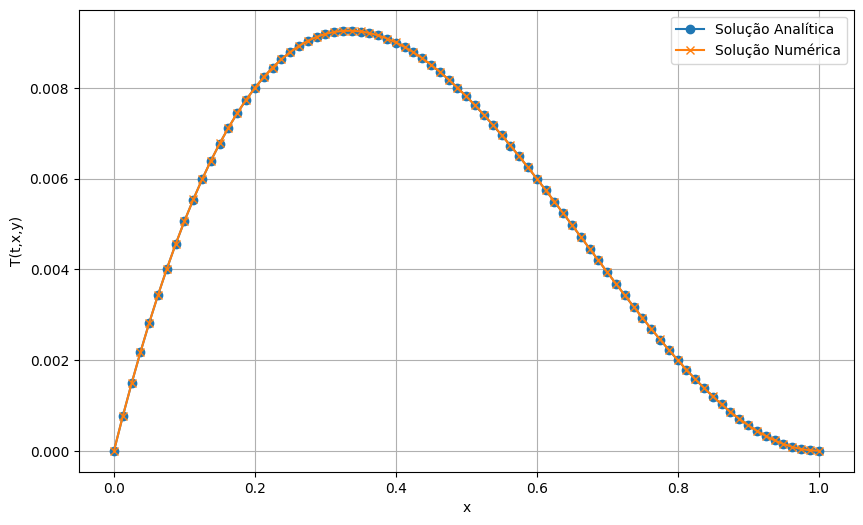

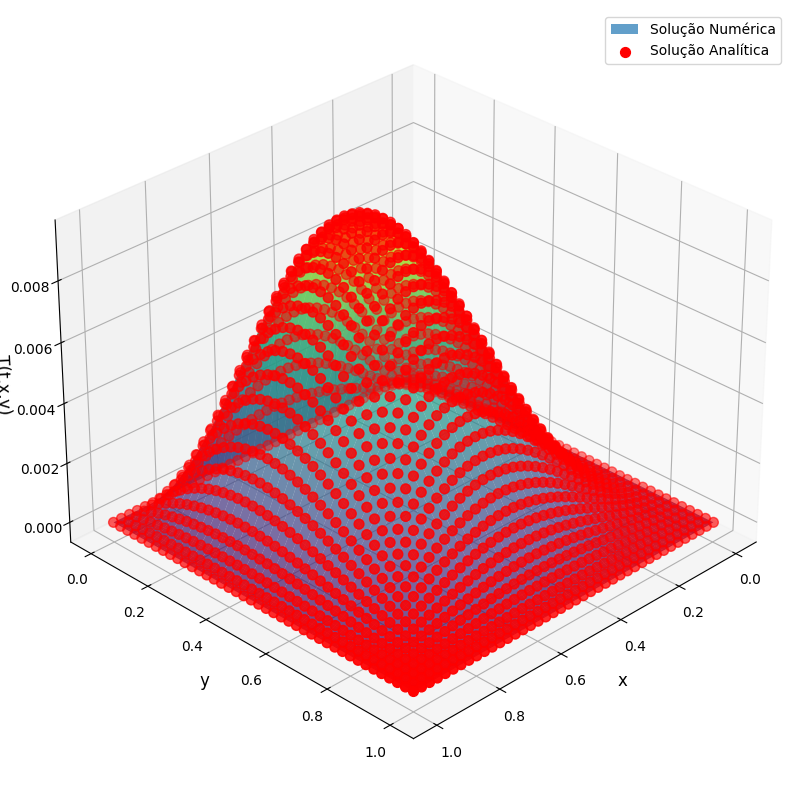


Running simulation for nx = 161



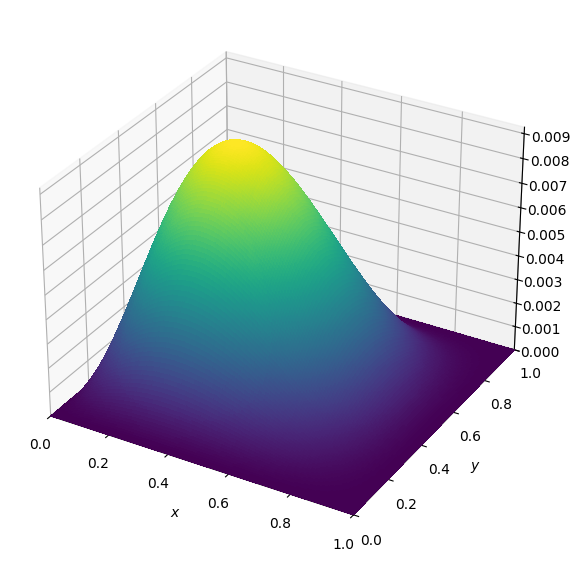

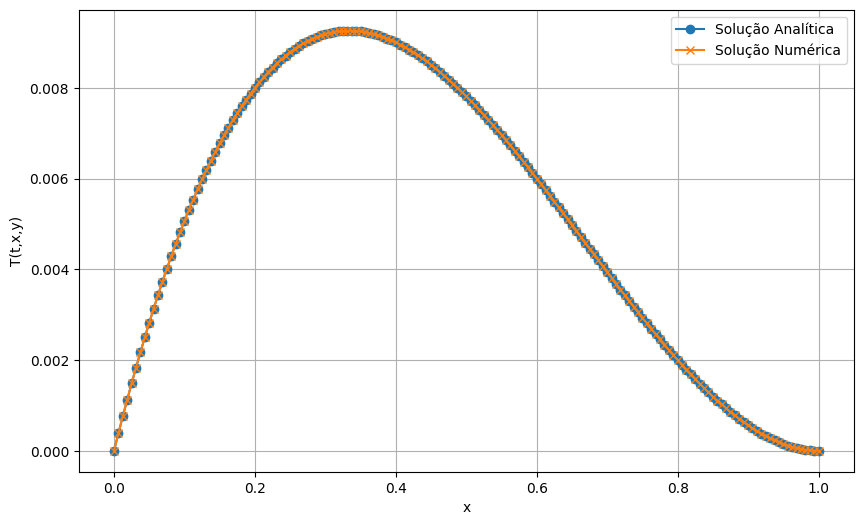

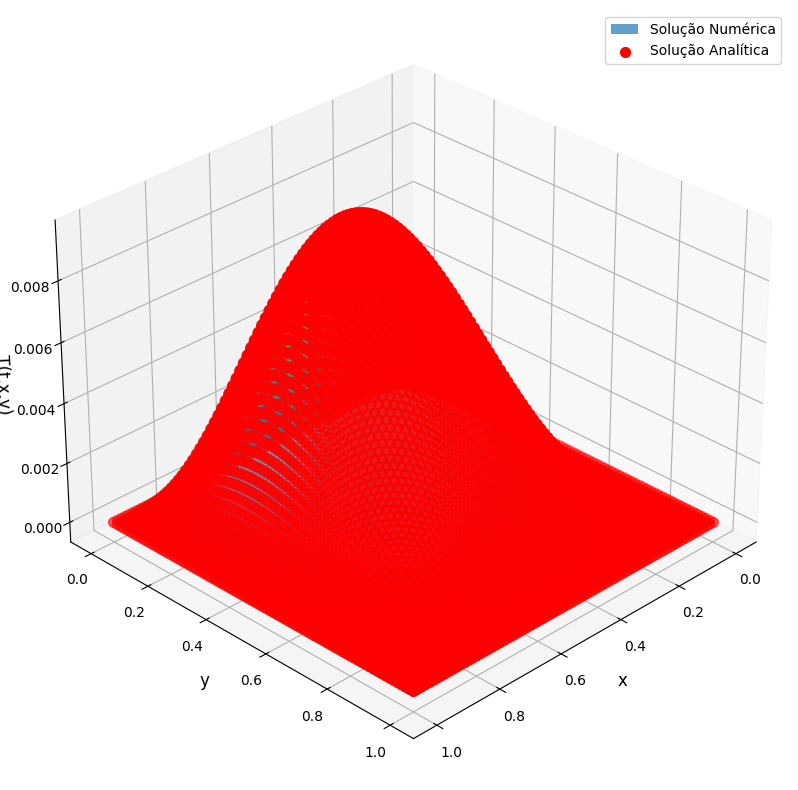


Convergence Analysis Table:
     N          h     dt_cfl                   Erro                 q_h            q_dt_cfl
0   11 1.0000e-01 2.5000e-03   0.030696086446142717                 NaN                 NaN
1   21 5.0000e-02 6.2500e-04   0.007666854966335983   2.001347939172716   1.000673969586358
2   41 2.5000e-02 1.5625e-04  0.0018982540740177733   2.013961784209536   1.006980892104768
3   81 1.2500e-02 3.9063e-05  0.0004046264331629856  2.2300106289767143  1.1150053144883572
4  161 6.2500e-03 9.7656e-06  3.222749463581006e-06   6.972154722459189  3.4860773612295946


In [29]:
# Run simulations
all_results, df_convergence = run_simulation(nx_values=[11,21,41,81,161])